# CCM-109 - Tópicos especiais de IA - Deep Learning

## Pipeline de detecção de deepfake

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jtlimo/ccm-109/blob/main/train.ipynb)

---

### Índice

1. [Configuração](#1-configuração)
2. [Dataset FF++](#2-dataset-faceforensics)
3. [Funções auxiliares](#3-funções-auxiliares)
4. [Treino](#4-treino)

## 1. Configuração

In [61]:
# @title instala dependências

%pip install -q tensorflow keras-hub


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [62]:
# @title Imports

import os, random
from collections import defaultdict, Counter
from pathlib import Path
import numpy as np
import keras_hub
import matplotlib.pyplot as plt



In [63]:
# @title Configurações

IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 5
LR = 1e-4
FEATURE_DIM = 768
DATASET_ROOT = "/dataset/FF"
FEATURES_CACHE = "/dataset/siglip2_features_keras.npz"

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Desativa GPU

import tensorflow as tf
from tensorflow import keras

AUTOTUNE = tf.data.AUTOTUNE

print(f"GPUs visíveis: {tf.config.list_physical_devices('GPU')}")
print(f'TensorFlow: {tf.__version__}')

GPUs visíveis: []
TensorFlow: 2.20.0


## 2. Dataset FaceForensics++

No arquivo **face_extraction.ipynb** foi realizada a extração dos rostos frame por frame nos vídeos do dataset. Para melhorar a otimização, foram utilizados os seguintes filtros na extração:

- SKIP_FRAMES = 9     
_0 = todos; 9 = pula 9 (processa 1 a cada 10)_

- MAX_FRAMES_PER_VIDEO = 30          
_None = todos; ex: 100 = máx 100 frames que contenham rostos são salvos_

- MAX_READ_LIMIT = 1000                 
_None = todos; ex: 1000 = máx 1000 frames lidos por vídeo_

- MAX_VIDEOS = None                 
_None = todos; ex: 10 = máx 10 vídeos processados_

Split padrão: **70% treino / 15% validação / 15% teste**.

| Índice | Classe 
|---|---
| 0 | real 
| 1 | fake

Há também o pré-processamento para o siglip2 que é o que será usado no modelo, as imagens são salvas em 224x224 (float 32)

## 3. Funções auxiliares

In [64]:
# @title Carrega Siglip2 sem a cabeça classificadora

input_data = {
  "images": np.ones(shape=(1, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32),
  "token_ids": np.zeros(shape=(1, 64), dtype=np.int32),
}

if os.path.exists("siglip2_base_patch16_224_original_backbone.keras"):
   print("Carregando backbone do SigLIP2 a partir do arquivo salvo...")
   try:
        backbone = keras.models.load_model("siglip2_base_patch16_224_original_backbone.keras")
   except Exception as e:
        print(f"Erro ao carregar o backbone localmente: {e}")
        print("Recarregando o backbone do SigLIP2 a partir do preset...")
        backbone = keras_hub.models.SigLIPBackbone.from_preset("siglip2_base_patch16_224")
        backbone.trainable = False
else:
  print("Baixando o backbone SigLIP2 do KerasHub...")
  backbone = keras_hub.models.SigLIPBackbone.from_preset("siglip2_base_patch16_224")
  backbone.trainable = False
  backbone.save("siglip2_base_patch16_224_original_backbone.keras")
  print("Salvo localmente")

out = backbone(input_data)

embeddings = backbone.get_vision_embeddings(input_data["images"])
print(f"Shape: {embeddings.shape}")

Baixando o backbone SigLIP2 do KerasHub...
Salvo localmente
Shape: (1, 768)


In [65]:
# @title Carrega imagens pré-processadas para o Siglip2

def collect_dataset(root):
    root = Path(root)
    paths, labels, vids = [], [], []
    for class_name, label in [("real", 0), ("fake", 1)]:
        class_dir = root / class_name
        if not class_dir.exists():
                continue
        for npy_file in class_dir.rglob("*_siglip2.npy"):
            paths.append(str(npy_file))
            labels.append(label)
            vids.append(npy_file.parent.name)
    return paths, np.array(labels, np.int32), np.array(vids)

npy_paths, labels, video_ids = collect_dataset(DATASET_ROOT)

print(f"Total: {len(npy_paths)} | Real: {sum(labels==0)} | Fake: {sum(labels==1)}")
print(f"Videos unicos: {len(set(video_ids))}")

real_vids = set(v for v, l in zip(video_ids, labels) if l == 0)
fake_vids = set(v for v, l in zip(video_ids, labels) if l == 1)
colisao = real_vids & fake_vids

if colisao:
    print(f"\n⚠️ {len(colisao)} videos com mesmo nome em real e fake!")
    video_ids = np.array([f"{'real' if l == 0 else 'fake'}_{v}" 
                          for v, l in zip(video_ids, labels)])
else:
    print("\n✓ Sem colisao")

for vid, c in Counter(video_ids).most_common(10):
    print(f"  {vid}: {c} frames")

Total: 278038 | Real: 40099 | Fake: 237939
Videos unicos: 9114

✓ Sem colisao
  869_780 (2): 143 frames
  869_780: 141 frames
  869_780 (5): 141 frames
  869_780 (4): 141 frames
  869_780 (3): 140 frames
  869: 139 frames
  447_431 (3): 71 frames
  447: 69 frames
  447_431 (4): 69 frames
  447_431: 69 frames


In [66]:
# @title Extrai features do Siglip2 e salva em cache .npz

def extract_all(paths, backbone, bs=32):
    feats = []
    for i in range(0, len(paths), bs):
        batch = np.stack([np.load(p) for p in paths[i:i+bs]])
        
        input_data = {
            "images": batch,
            "token_ids": np.zeros(shape=(batch.shape[0], 64), dtype=np.int32),
        }
        
        emb = backbone.get_vision_embeddings(input_data["images"]).numpy()
        feats.append(emb)
        
        if i % 1000 == 0:
            print(f"{i}/{len(paths)}")
    
    return np.concatenate(feats, axis=0)

if Path(FEATURES_CACHE).exists():
    d = np.load(FEATURES_CACHE)
    features, labels, video_ids = d["features"], d["labels"], d["video_ids"]
    print("Cache carregado")
else:
    features = extract_all(npy_paths, backbone)
    np.savez(FEATURES_CACHE, features=features, labels=labels, video_ids=video_ids)
    print("Features extraidas e salvas")

print(f"Features: {features.shape}")

Cache carregado
Features: (278038, 768)


## 4. Treino

In [67]:
# @title Split dataset em treino/validação/teste por vídeo
def split_by_video(features, labels, vids, train=0.7, val=0.15, seed=42):
    random.seed(seed)
    vid_to_idx = defaultdict(list)
    for i, v in enumerate(vids):
        vid_to_idx[v].append(i)
    
    all_vids = list(vid_to_idx.keys())
    random.shuffle(all_vids)
    
    n = len(all_vids)
    n_train = int(n * train)
    n_val = int(n * val)

    train_v = all_vids[:n_train]
    val_v = all_vids[n_train:n_train + n_val]
    test_v = all_vids[n_train + n_val:]
    
    def idxs(vlist):
        return [i for v in vlist for i in vid_to_idx[v]]
    
    return (features[idxs(train_v)], labels[idxs(train_v)],
            features[idxs(val_v)], labels[idxs(val_v)],
            features[idxs(test_v)], labels[idxs(test_v)],
            test_v)

X_train, y_train, X_val, y_val, X_test, y_test, test_vids = split_by_video(features, labels, video_ids)
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


Train: 194519 | Val: 41937 | Test: 41582


In [68]:
# @title Cria datasets de treino, validação e teste

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(len(X_train)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(AUTOTUNE)


In [69]:
# @title Constrói o modelo completo
model = keras.Sequential([
    keras.layers.Input(shape=(FEATURE_DIM,)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=keras.optimizers.Adam(LR), loss='binary_crossentropy',
              metrics=['accuracy', keras.metrics.AUC(name='auc')])
model.summary()

for ilayer, layer in enumerate(model.layers):
    print("{:3.0f} {:10}".format(ilayer, layer.name))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_228 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_229 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_230 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 561,665 (2.14 MB)

 Trainable params: 559,873 (2.14 MB)

 Non-trainable params: 1,792 (7.00 KB)

  0 dense_4   
  1 batch_normalization_3
  2 dropout_228
  3 dense_5   
  4 batch_normalization_4
  5 dropout_229
  6 dense_6   
  7 batch_normalization_5
  8 dropout_230
  9 dense_7   


In [70]:
# @title Callbacks

from metrics_logger import MetricsLogger

callbacks = [
    MetricsLogger(),
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max', verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=2, min_lr=1e-7, mode='max', verbose=1),
    keras.callbacks.ModelCheckpoint(monitor='val_auc', filepath='model.{epoch:02d}-{val_auc:.4f}.keras', save_best_only=True, mode='max', verbose=1)
]

In [71]:
# @title Treinamento

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

print(f'\nAcurácia de validação (Fase 1): {history.history["val_accuracy"][-1]:.1%}')

Epoch 1/5


/home/jessicafileto/Documents/workspace/ufabc/ccm-109/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


3032/3040 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7757 - auc: 0.6860 - loss: 0.4840
📊 Época 1: loss=0.4837, val_loss=0.3040, auc=0.6861, val_auc=0.8385, acc=0.7759, val_acc=0.8746, lr=1.00e-04

Epoch 1: val_auc improved from None to 0.83852, saving model to model.01-0.8385.keras

Epoch 1: finished saving model to model.01-0.8385.keras
3040/3040 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.7759 - auc: 0.6861 - loss: 0.4837 - val_accuracy: 0.8746 - val_auc: 0.8385 - val_loss: 0.3040 - learning_rate: 1.0000e-04
Epoch 2/5
3037/3040 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8710 - auc: 0.8372 - loss: 0.3143
📊 Época 2: loss=0.3142, val_loss=0.2771, auc=0.8372, val_auc=0.8720, acc=0.8711, val_acc=0.8875, lr=1.00e-04

Epoch 2: val_auc improved from 0.83852 to 0.87200, saving model to model.02-0.8720.keras

Epoch 2: finished saving model to model.02-0.8720.keras
3040/3040 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.8711 - auc: 0.8372 - loss: 0.3142 - val_accuracy: 0.8875 - va

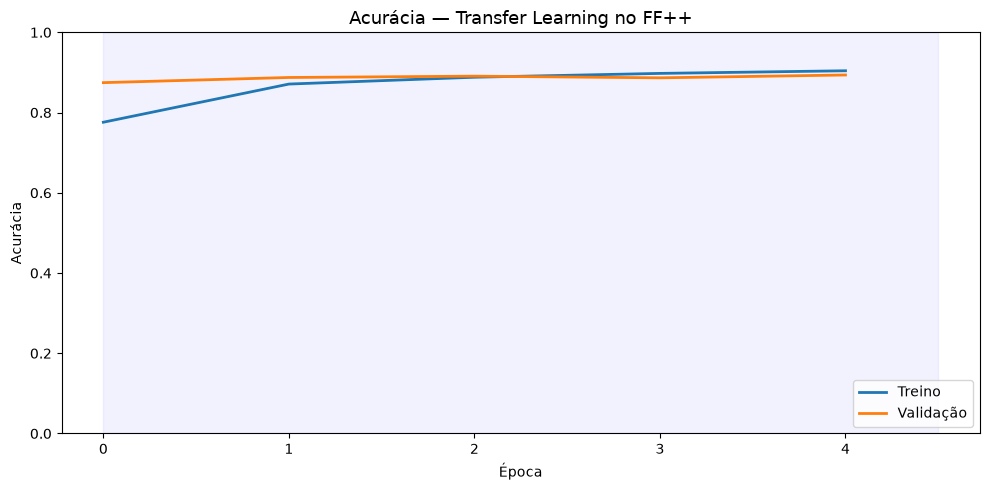

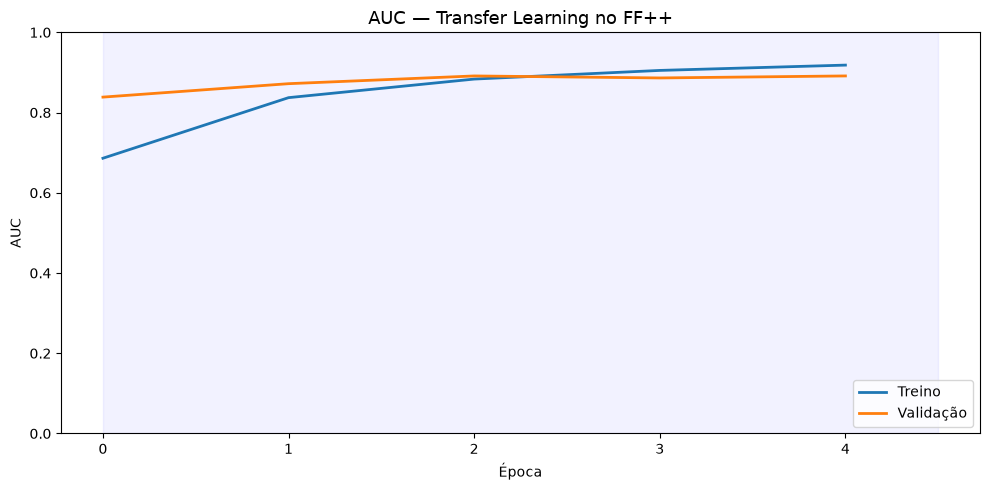

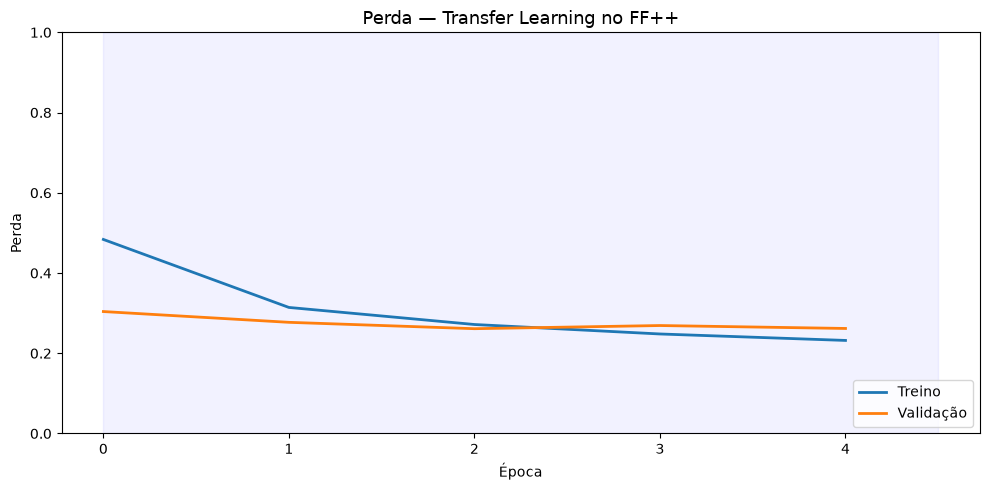

In [72]:
# @title Plota métricas de treino e validação

acc_all     = history.history['accuracy']    
val_acc_all = history.history['val_accuracy']

auc_all     = history.history['auc']    
val_auc_all = history.history['val_auc']

loss_all     = history.history['loss']
val_loss_all = history.history['val_loss']


# Acurácia

plt.figure(figsize=(10, 5))
plt.plot(acc_all,     label='Treino',     linewidth=2)
plt.plot(val_acc_all, label='Validação',  linewidth=2)
plt.fill_betweenx([0, 1], 0, EPOCHS - 0.5,
                  alpha=0.05, color='blue')
plt.title('Acurácia — Transfer Learning no FF++', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


# AUC

plt.figure(figsize=(10, 5))
plt.plot(auc_all,     label='Treino',     linewidth=2)
plt.plot(val_auc_all, label='Validação',  linewidth=2)
plt.fill_betweenx([0, 1], 0, EPOCHS - 0.5,
                  alpha=0.05, color='blue')
plt.title('AUC — Transfer Learning no FF++', fontsize=13)
plt.xlabel('Época')
plt.ylabel('AUC')
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


# Loss

plt.figure(figsize=(10, 5))
plt.plot(loss_all,     label='Treino',     linewidth=2)
plt.plot(val_loss_all, label='Validação',  linewidth=2)
plt.fill_betweenx([0, 1], 0, EPOCHS - 0.5,
                  alpha=0.05, color='blue')
plt.title('Perda — Transfer Learning no FF++', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()




In [73]:
#@title Descongela as últimas 4 camadas do vision encoder
model.trainable = True

freeze_until = len(backbone.vision_encoder.layers) - 4
for layer in backbone.vision_encoder.layers[:freeze_until]:
    layer.trainable = False

trainable = sum(1 for l in model.layers if l.trainable)
frozen    = sum(1 for l in model.layers if not l.trainable)
print(f'Camadas treináveis na base: {trainable}')
print(f'Camadas congeladas na base: {frozen}')

trainable_ve = sum(1 for l in backbone.vision_encoder.layers if l.trainable)
frozen_ve    = sum(1 for l in backbone.vision_encoder.layers if not l.trainable)
print(f'Vision encoder — Treináveis: {trainable_ve}, Congeladas: {frozen_ve}')

backbone.save("siglip2_base_patch16_224_finetune_backbone.keras")


Camadas treináveis na base: 10
Camadas congeladas na base: 0
Vision encoder — Treináveis: 0, Congeladas: 16


In [74]:
# @title Re-compila com taxa de aprendizado menor — Fase 2

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary(show_trainable=True)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ dense_4 (Dense)             │ (None, 512)           │    393,728 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization_3       │ (None, 512)           │      2,048 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_228 (Dropout)       │ (None, 512)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_5 (Dense)             │ (None, 256)           │    131,328 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization_4       │ (None, 256)           │      1,024 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_229 (Dropout)       │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_6 (Dense)             │ (None, 128)           │     32,896 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization_5       │ (None, 128)           │        512 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_230 (Dropout)       │ (None, 128)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_7 (Dense)             │ (None, 1)             │        129 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 561,665 (2.14 MB)

 Trainable params: 559,873 (2.14 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [75]:
#@title Treinamento Fase 2 (5 epochs, LR=1e-5)

EPOCHS_2 = 5

history2 = model.fit(
    train_ds,
    epochs=EPOCHS + EPOCHS_2,
    initial_epoch=EPOCHS,
    validation_data=val_ds,
    verbose=1,
    callbacks=callbacks
)

print(f'\nAcurácia de validação (Fase 2): {history2.history["val_accuracy"][-1]:.1%}')

Epoch 6/10
3037/3040 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9122 - auc: 0.9315 - loss: 0.2144
📊 Época 6: loss=0.2145, val_loss=0.2592, auc=0.9315, val_auc=0.8970, acc=0.9121, val_acc=0.8938, lr=1.00e-05

Epoch 6: val_auc improved from 0.89130 to 0.89704, saving model to model.06-0.8970.keras

Epoch 6: finished saving model to model.06-0.8970.keras
3040/3040 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9121 - auc: 0.9315 - loss: 0.2145 - val_accuracy: 0.8938 - val_auc: 0.8970 - val_loss: 0.2592 - learning_rate: 1.0000e-05
Epoch 7/10
3038/3040 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9142 - auc: 0.9346 - loss: 0.2099
📊 Época 7: loss=0.2099, val_loss=0.2624, auc=0.9346, val_auc=0.8974, acc=0.9142, val_acc=0.8931, lr=1.00e-05

Epoch 7: val_auc improved from 0.89704 to 0.89742, saving model to model.07-0.8974.keras

Epoch 7: finished saving model to model.07-0.8974.keras
3040/3040 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9142 - auc: 0.9346 - loss: 0.2099 - val_accura

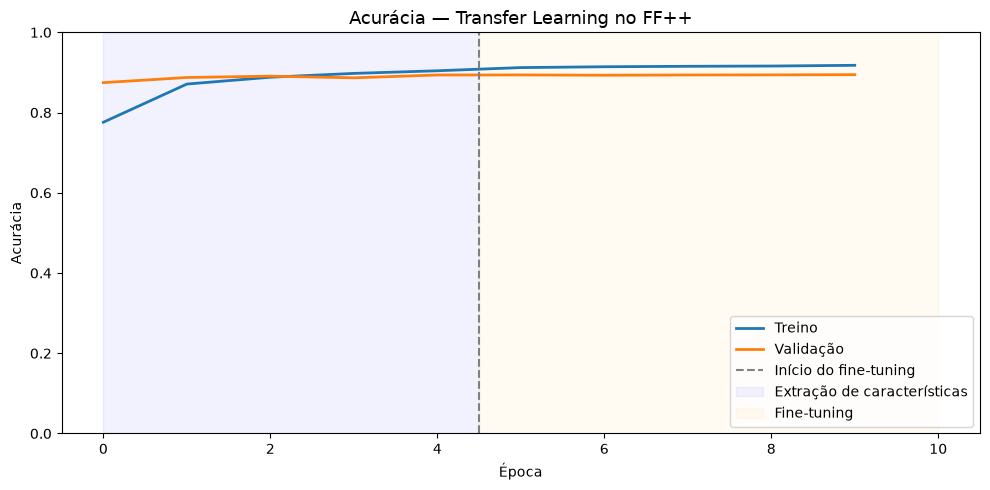

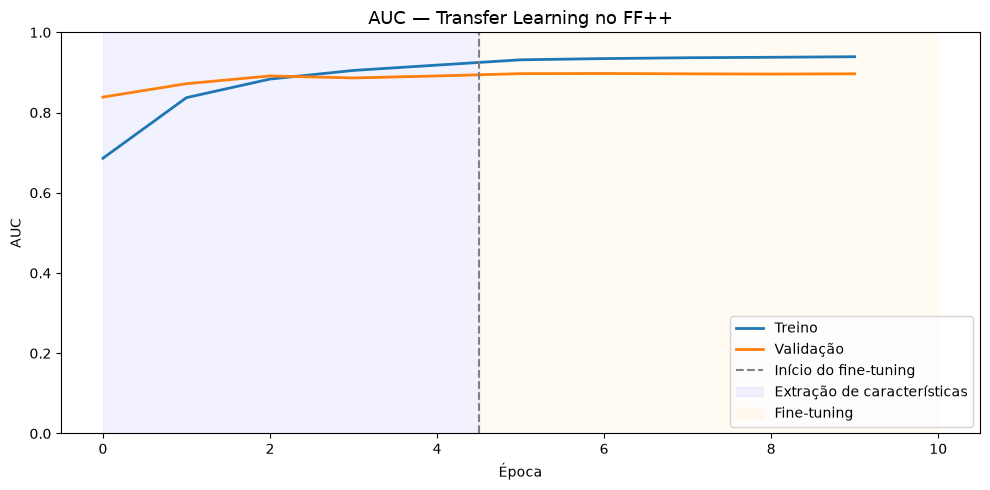

In [76]:
# @title Concatena históricos e plota
acc_all     = history.history['accuracy']     + history2.history['accuracy']
val_acc_all = history.history['val_accuracy'] + history2.history['val_accuracy']

plt.figure(figsize=(10, 5))
plt.plot(acc_all,     label='Treino',     linewidth=2)
plt.plot(val_acc_all, label='Validação',  linewidth=2)
plt.axvline(x=EPOCHS - 0.5, color='gray', linestyle='--', linewidth=1.5,
            label='Início do fine-tuning')
plt.fill_betweenx([0, 1], 0, EPOCHS - 0.5,
                  alpha=0.05, color='blue',  label='Extração de características')
plt.fill_betweenx([0, 1], EPOCHS - 0.5, len(acc_all),
                  alpha=0.05, color='orange', label='Fine-tuning')
plt.title('Acurácia — Transfer Learning no FF++', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()



auc_all     = history.history['auc']     + history2.history['auc']
val_auc_all = history.history['val_auc'] + history2.history['val_auc']

plt.figure(figsize=(10, 5))
plt.plot(auc_all,     label='Treino',     linewidth=2)
plt.plot(val_auc_all, label='Validação',  linewidth=2)
plt.axvline(x=EPOCHS - 0.5, color='gray', linestyle='--', linewidth=1.5,
            label='Início do fine-tuning')
plt.fill_betweenx([0, 1], 0, EPOCHS - 0.5,
                  alpha=0.05, color='blue',  label='Extração de características')
plt.fill_betweenx([0, 1], EPOCHS - 0.5, len(auc_all),
                  alpha=0.05, color='orange', label='Fine-tuning')
plt.title('AUC — Transfer Learning no FF++', fontsize=13)
plt.xlabel('Época')
plt.ylabel('AUC')
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()